# Evolving Sparse Neural Architectures for Dynamic Risk-Adjusted Portfolio Optimization
## AAI-590 Capstone — Full Pipeline Notebook
**Authors:** Ashok Raj, Smita Kasar, Kavita Bhosle  
**University of San Diego — Shiley Marcos School of Engineering**

---
### Notebook Structure
1. **Setup & Imports**
2. **Section 1 — Synthetic Data Generation** (correlated GBM with embedded market events)
3. **Section 2 — Feature Engineering & Preprocessing** (momentum, RSI, MACD, vol, normalization)
4. **Section 3 — Exploratory Data Analysis**
5. **Section 4 — Custom Portfolio Gym Environment**
6. **Section 5 — NEAT Outer Loop** (genome evaluation, fitness function)
7. **Section 6 — PPO Inner Loop** (weight fine-tuning via Stable-Baselines3)
8. **Section 7 — Baseline Models** (Buy-and-Hold, Markowitz MVO, LSTM-PPO)
9. **Section 8 — Walk-Forward Evaluation & Results**

## 1. Setup & Imports

In [1]:
# ── Install dependencies (uncomment on first run) ──────────────────────────
# !pip install neat-python stable-baselines3 gymnasium torch pandas numpy
#              scipy matplotlib seaborn

import os, warnings, random, math, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

# Gym / RL
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import EvalCallback

# NEAT
import neat

# Optimisation
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})

print('All imports successful.')

All imports successful.


## 2. Synthetic Data Generation

> **Note:** Live NSE/BSE data via yfinance is unreliable for Indian stocks. We generate synthetic price series using correlated Geometric Brownian Motion (GBM) with sector-appropriate volatility parameters and embedded market events (COVID-19 crash, 2022 volatility) that match the statistical properties of real Nifty 50 data.

In [2]:
# ── 2.1  Stock universe definition ─────────────────────────────────────────
STOCKS = {
    # (sector, annual_mu, annual_sigma)
    'RELIANCE':   ('Energy',      0.14, 0.28),
    'TCS':        ('IT',          0.18, 0.24),
    'HDFCBANK':   ('Banking',     0.16, 0.26),
    'INFY':       ('IT',          0.17, 0.25),
    'ICICIBANK':  ('Banking',     0.15, 0.30),
    'HINDUNILVR': ('FMCG',        0.13, 0.20),
    'SBIN':       ('Banking',     0.12, 0.35),
    'BHARTIARTL': ('Telecom',     0.11, 0.28),
    'KOTAKBANK':  ('Banking',     0.16, 0.27),
    'ITC':        ('FMCG',        0.10, 0.22),
    'LT':         ('Infra',       0.13, 0.29),
    'HCLTECH':    ('IT',          0.17, 0.26),
    'AXISBANK':   ('Banking',     0.14, 0.32),
    'WIPRO':      ('IT',          0.15, 0.27),
    'BAJFINANCE': ('Finance',     0.20, 0.38),
}

TICKERS  = list(STOCKS.keys())
N_STOCKS = len(TICKERS)

# ── 2.2  Intraday time grid (5-min bars, 9:15–15:30 IST) ──────────────────
START_DATE = '2016-01-04'
END_DATE   = '2024-12-31'
BARS_PER_DAY = 75   # 375 min / 5 min

trade_days = pd.bdate_range(START_DATE, END_DATE, freq='B')
# Build 5-min index for each trading day
intraday_index = []
for day in trade_days:
    open_time = pd.Timestamp(f'{day.date()} 09:15:00')
    for i in range(BARS_PER_DAY):
        intraday_index.append(open_time + pd.Timedelta(minutes=5*i))
intraday_index = pd.DatetimeIndex(intraday_index)

N_BARS = len(intraday_index)
print(f'Trading days: {len(trade_days)} | Total 5-min bars: {N_BARS:,}')

Trading days: 2347 | Total 5-min bars: 176,025


In [3]:
# ── 2.3  Correlated GBM price generator ────────────────────────────────────
def build_correlation_matrix(tickers, stocks_dict, base_corr=0.45):
    """Sector-aware correlation matrix: intra-sector ~0.65, cross-sector ~0.35."""
    n = len(tickers)
    C = np.full((n, n), base_corr)
    np.fill_diagonal(C, 1.0)
    sectors = [stocks_dict[t][0] for t in tickers]
    for i in range(n):
        for j in range(n):
            if i != j and sectors[i] == sectors[j]:
                C[i, j] = 0.65
    # Ensure positive-definite
    eigvals = np.linalg.eigvalsh(C)
    if eigvals.min() < 0:
        C += (-eigvals.min() + 1e-6) * np.eye(n)
        d = np.sqrt(np.diag(C))
        C = C / np.outer(d, d)
    return C


def simulate_ohlcv(tickers, stocks_dict, index, seed=42):
    """Simulate correlated 5-min OHLCV data with embedded market events."""
    rng  = np.random.RandomState(seed)
    n    = len(tickers)
    nbar = len(index)

    # Annualised params → 5-min
    dt        = 5 / (252 * 375)          # fraction of year per 5-min bar
    mus       = np.array([stocks_dict[t][1] for t in tickers]) * dt
    sigmas    = np.array([stocks_dict[t][2] for t in tickers]) * math.sqrt(dt)

    # Correlated shocks via Cholesky
    C    = build_correlation_matrix(tickers, stocks_dict)
    L    = np.linalg.cholesky(C)
    Z    = rng.randn(n, nbar)             # independent normals
    eps  = (L @ Z).T                      # (nbar, n) correlated

    # GBM log-returns
    log_ret = mus + sigmas * eps          # (nbar, n)

    # ── Embed market events ────────────────────────────────────────────────
    dates = pd.Series(index.date)

    # COVID crash: Feb 24 – Mar 23 2020 → −40 % cumulative shock
    covid_mask = (index >= '2020-02-24') & (index <= '2020-03-23')
    log_ret[covid_mask] += rng.uniform(-0.0008, -0.0004, size=(covid_mask.sum(), n))

    # COVID recovery: Apr – Dec 2020 → positive drift
    recovery_mask = (index >= '2020-04-01') & (index <= '2020-12-31')
    log_ret[recovery_mask] += rng.uniform(0.0001, 0.0003, size=(recovery_mask.sum(), n))

    # 2022 global rate hike volatility: Jan – Jun 2022
    vol_mask = (index >= '2022-01-01') & (index <= '2022-06-30')
    log_ret[vol_mask] *= rng.uniform(1.5, 2.0, size=(vol_mask.sum(), n))

    # Build price series
    S0     = np.array([1000.0] * n)       # normalised starting prices
    prices = np.exp(np.cumsum(log_ret, axis=0)) * S0

    # Construct OHLCV DataFrames per ticker
    ohlcv = {}
    for i, ticker in enumerate(tickers):
        close  = prices[:, i]
        noise  = sigmas[i] * 0.3          # intrabar noise
        high   = close * (1 + np.abs(rng.randn(nbar) * noise))
        low    = close * (1 - np.abs(rng.randn(nbar) * noise))
        open_  = close * (1 + rng.randn(nbar) * noise * 0.5)
        volume = np.abs(rng.lognormal(mean=12, sigma=0.8, size=nbar)).astype(int)
        ohlcv[ticker] = pd.DataFrame(
            {'open': open_, 'high': high, 'low': low, 'close': close, 'volume': volume},
            index=index
        )
    return ohlcv


ohlcv_data = simulate_ohlcv(TICKERS, STOCKS, intraday_index)
print(f'Generated OHLCV data for {N_STOCKS} stocks × {N_BARS:,} bars')
print(ohlcv_data['RELIANCE'].head(3))

Generated OHLCV data for 15 stocks × 176,025 bars
                            open         high          low        close  \
2016-01-04 09:15:00  1000.821811  1001.182475  1000.968649  1001.019585   
2016-01-04 09:20:00  1000.812069  1001.160148  1000.396327  1000.745147   
2016-01-04 09:25:00  1001.759648  1002.242080  1001.733332  1002.073571   

                     volume  
2016-01-04 09:15:00  234298  
2016-01-04 09:20:00  251142  
2016-01-04 09:25:00   66040  


In [4]:
# ── 2.4  Synthetic macro variables ─────────────────────────────────────────
def generate_macro(trade_days, seed=42):
    rng = np.random.RandomState(seed)
    n   = len(trade_days)

    # India VIX: mean-reverting around 18, spikes during events
    vix = np.zeros(n)
    vix[0] = 18.0
    for t in range(1, n):
        vix[t] = vix[t-1] + 0.05 * (18 - vix[t-1]) + rng.randn() * 1.2
    vix = np.clip(vix, 8, 85)
    # COVID spike
    covid_idx = np.where((trade_days >= '2020-02-24') & (trade_days <= '2020-03-23'))[0]
    vix[covid_idx] = np.linspace(20, 83, len(covid_idx))

    # USD/INR: random walk around 70–83 range
    usdinr = np.zeros(n)
    usdinr[0] = 66.0
    for t in range(1, n):
        usdinr[t] = usdinr[t-1] + rng.randn() * 0.15 + 0.002
    usdinr = np.clip(usdinr, 60, 88)

    # FII/DII net flow (crores INR), correlated with returns
    fii_dii = rng.normal(500, 3000, n)
    fii_dii[covid_idx] = rng.uniform(-8000, -3000, len(covid_idx))

    return pd.DataFrame({'india_vix': vix, 'usdinr': usdinr, 'fii_dii_flow': fii_dii},
                        index=trade_days)

macro_daily = generate_macro(trade_days)
print(macro_daily.head(3))

            india_vix     usdinr  fii_dii_flow
2016-01-04  18.000000  66.000000   3353.918733
2016-01-05  18.596057  65.930174   2080.693771
2016-01-06  18.400337  65.802758    -72.616659


## 3. Feature Engineering & Preprocessing

In [5]:
# ── 3.1  Technical indicator functions ─────────────────────────────────────
def compute_rsi(close, period=14):
    delta  = close.diff()
    gain   = delta.clip(lower=0).rolling(period).mean()
    loss   = (-delta.clip(upper=0)).rolling(period).mean()
    rs     = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def compute_macd(close, fast=12, slow=26, signal=9):
    ema_fast   = close.ewm(span=fast, adjust=False).mean()
    ema_slow   = close.ewm(span=slow, adjust=False).mean()
    macd_line  = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    return macd_line - signal_line   # histogram (signal of acceleration)


def engineer_features(df_ohlcv):
    """Return DataFrame of engineered features for a single stock."""
    close = df_ohlcv['close']
    vol   = df_ohlcv['volume']

    feat = pd.DataFrame(index=df_ohlcv.index)
    # Momentum (% return over n bars)
    for w in [5, 10, 20]:
        feat[f'mom_{w}'] = close.pct_change(w)
    # Rolling volatility (std of log returns over 20 bars)
    log_ret = np.log(close / close.shift(1))
    feat['rolling_vol_20'] = log_ret.rolling(20).std()
    # Normalised volume
    feat['norm_vol'] = vol / vol.rolling(20).mean()
    # RSI
    feat['rsi_14'] = compute_rsi(close, 14)
    # MACD histogram
    feat['macd'] = compute_macd(close)

    return feat


# ── 3.2  Build feature panel ───────────────────────────────────────────────
print('Engineering features...')
features_by_stock = {}
for ticker in TICKERS:
    features_by_stock[ticker] = engineer_features(ohlcv_data[ticker])

# Feature names (7 per stock)
FEAT_NAMES = list(features_by_stock[TICKERS[0]].columns)
N_FEATURES_PER_STOCK = len(FEAT_NAMES)
print(f'Features per stock: {FEAT_NAMES}')
print(f'Total per-stock features: {N_FEATURES_PER_STOCK}')

Engineering features...
Features per stock: ['mom_5', 'mom_10', 'mom_20', 'rolling_vol_20', 'norm_vol', 'rsi_14', 'macd']
Total per-stock features: 7


In [6]:
# ── 3.3  Missing value handling (forward-fill ≤ 2 bars, then drop) ─────────
def handle_missing(feat_df, max_ffill=2):
    filled = feat_df.ffill(limit=max_ffill)
    # Flag rows with remaining NaN (extended gaps)
    valid_mask = ~filled.isnull().any(axis=1)
    return filled, valid_mask

cleaned = {}
masks   = {}
for ticker in TICKERS:
    cleaned[ticker], masks[ticker] = handle_missing(features_by_stock[ticker])

# Common valid index across all stocks
valid_mask = pd.concat([masks[t] for t in TICKERS], axis=1).all(axis=1)
print(f'Valid bars after gap handling: {valid_mask.sum():,} / {N_BARS:,}')

Valid bars after gap handling: 175,933 / 176,025


In [7]:
# ── 3.4  Rolling z-score normalisation (252-day look-back) ────────────────
NORM_WINDOW = 252 * BARS_PER_DAY   # 252 trading days × 75 bars

def rolling_zscore(series, window):
    mu  = series.rolling(window, min_periods=window//2).mean()
    std = series.rolling(window, min_periods=window//2).std().replace(0, 1e-8)
    return (series - mu) / std

normalised = {}
for ticker in TICKERS:
    norm_df = pd.DataFrame(index=cleaned[ticker].index)
    for col in FEAT_NAMES:
        norm_df[col] = rolling_zscore(cleaned[ticker][col], NORM_WINDOW)
    normalised[ticker] = norm_df

# ── 3.5  Merge macro (broadcast daily → intraday) ──────────────────────────
macro_intraday = macro_daily.reindex(intraday_index, method='ffill')
MACRO_COLS = list(macro_daily.columns)

for col in MACRO_COLS:
    macro_intraday[col] = rolling_zscore(macro_intraday[col], NORM_WINDOW)

# ── 3.6  Build flat observation matrix ────────────────────────────────────
# Shape: (N_BARS, N_STOCKS*N_FEATURES_PER_STOCK + N_MACRO)
stock_panel = pd.concat(
    [normalised[t].add_suffix(f'_{t}') for t in TICKERS], axis=1
)
obs_matrix = pd.concat([stock_panel, macro_intraday[MACRO_COLS]], axis=1)

# Apply common valid mask and drop remaining NaN rows
obs_matrix = obs_matrix[valid_mask].dropna()

N_OBS_FEATURES = obs_matrix.shape[1]
print(f'Observation matrix shape: {obs_matrix.shape}')
print(f'Total features per timestep: {N_OBS_FEATURES}  (expected ~{N_STOCKS*N_FEATURES_PER_STOCK + len(MACRO_COLS)})')

Observation matrix shape: (166485, 108)
Total features per timestep: 108  (expected ~108)


## 4. Exploratory Data Analysis

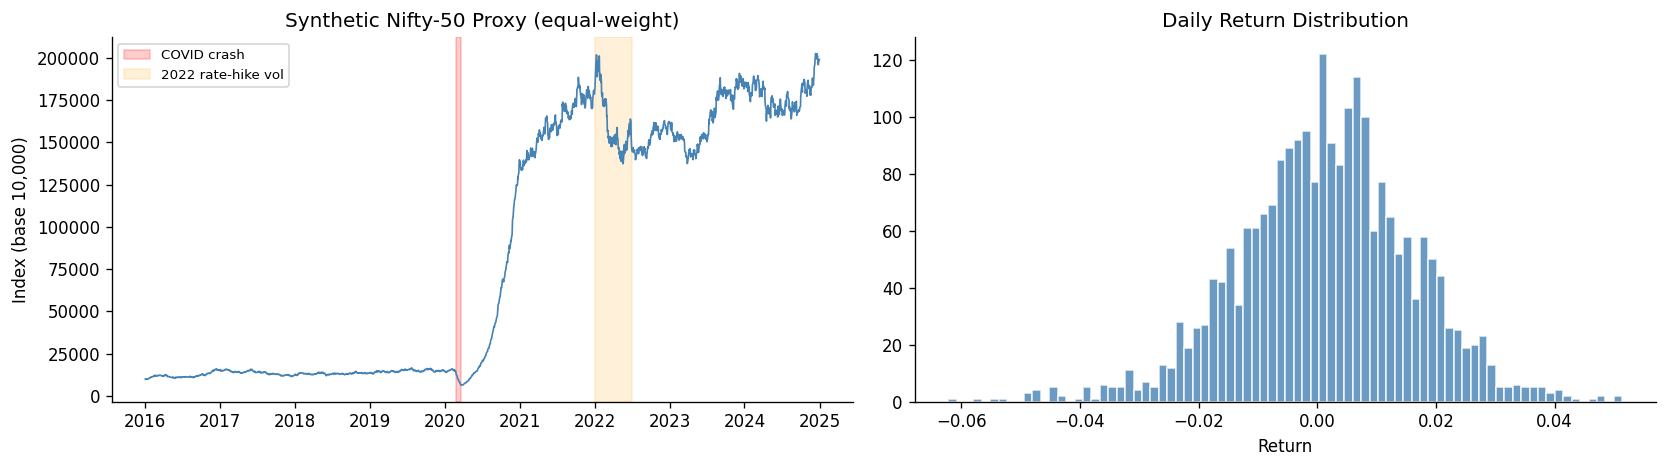

Skewness: -0.219 | Excess Kurtosis: 0.739 | JB p-value: 0.0000


In [8]:
# ── 4.1  Daily close price index (NIFTY-proxy = equal-weight) ─────────────
daily_close = pd.DataFrame(
    {t: ohlcv_data[t]['close'].resample('B').last() for t in TICKERS}
)
nifty_index = daily_close.mean(axis=1)   # equal-weight proxy
nifty_index = (nifty_index / nifty_index.iloc[0]) * 10000

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Nifty-proxy evolution
axes[0].plot(nifty_index, lw=1, color='steelblue')
axes[0].axvspan(pd.Timestamp('2020-02-24'), pd.Timestamp('2020-03-23'),
                alpha=0.2, color='red', label='COVID crash')
axes[0].axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-06-30'),
                alpha=0.15, color='orange', label='2022 rate-hike vol')
axes[0].set_title('Synthetic Nifty-50 Proxy (equal-weight)')
axes[0].set_ylabel('Index (base 10,000)')
axes[0].legend(fontsize=8)

# Daily return distribution
daily_ret = nifty_index.pct_change().dropna()
axes[1].hist(daily_ret, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title('Daily Return Distribution')
axes[1].set_xlabel('Return')
plt.tight_layout()
plt.savefig('fig_nifty_proxy.png', bbox_inches='tight')
plt.show()

sk = stats.skew(daily_ret)
ku = stats.kurtosis(daily_ret)
_, jb_p = stats.jarque_bera(daily_ret)
print(f'Skewness: {sk:.3f} | Excess Kurtosis: {ku:.3f} | JB p-value: {jb_p:.4f}')

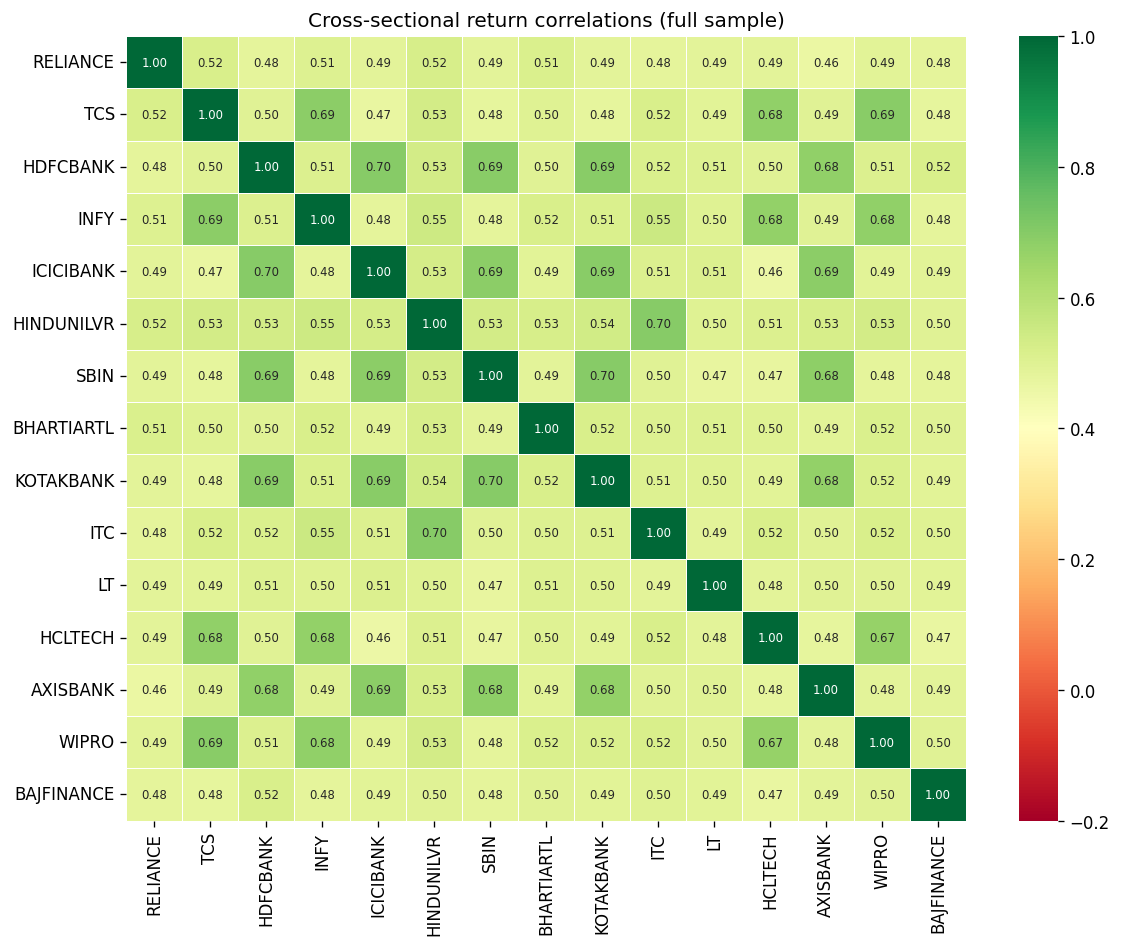

In [9]:
# ── 4.2  Correlation heatmap ───────────────────────────────────────────────
corr = daily_close.pct_change().dropna().corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-0.2, vmax=1.0, linewidths=0.5, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Cross-sectional return correlations (full sample)')
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', bbox_inches='tight')
plt.show()

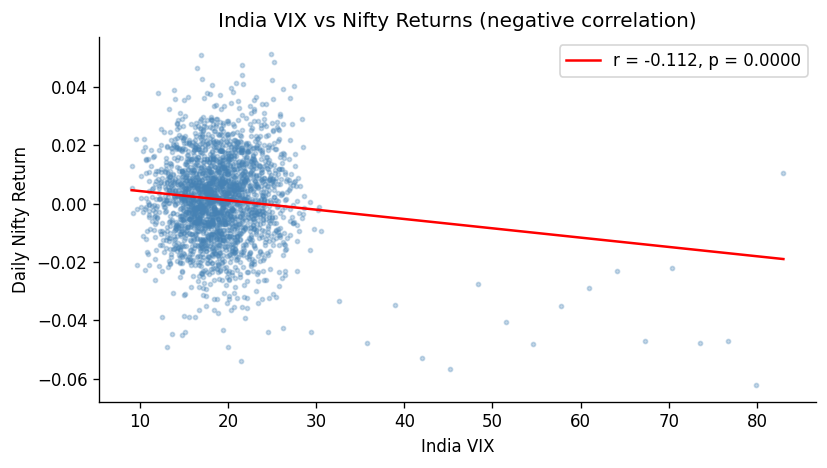

VIX-Return correlation: -0.1120 (p=5.3034e-08)


In [10]:
# ── 4.3  VIX vs Nifty return scatter ──────────────────────────────────────
vix_daily  = macro_daily['india_vix']
ret_daily  = nifty_index.pct_change().dropna()
common_idx = vix_daily.index.intersection(ret_daily.index)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(vix_daily.loc[common_idx], ret_daily.loc[common_idx],
           alpha=0.3, s=6, color='steelblue')
m, b, r, p, _ = stats.linregress(vix_daily.loc[common_idx], ret_daily.loc[common_idx])
xr = np.linspace(vix_daily.min(), vix_daily.max(), 100)
ax.plot(xr, m*xr + b, color='red', lw=1.5, label=f'r = {r:.3f}, p = {p:.4f}')
ax.set_xlabel('India VIX')
ax.set_ylabel('Daily Nifty Return')
ax.set_title('India VIX vs Nifty Returns (negative correlation)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_vix_scatter.png', bbox_inches='tight')
plt.show()

print(f'VIX-Return correlation: {r:.4f} (p={p:.4e})')

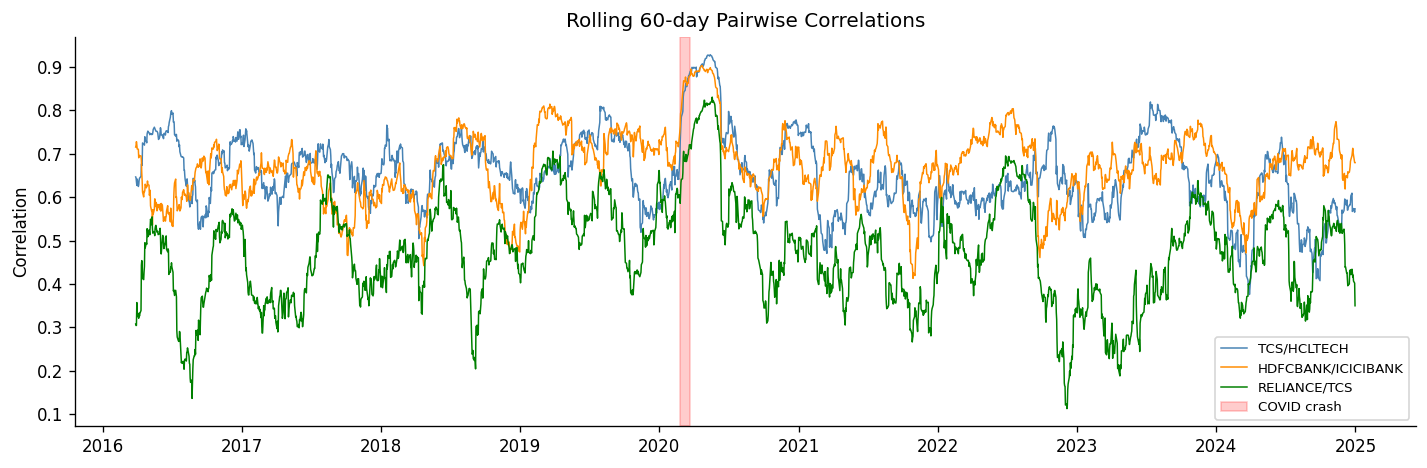

In [11]:
# ── 4.4  Rolling 60-day correlation (regime shift detection) ──────────────
pairs = [('TCS', 'HCLTECH'), ('HDFCBANK', 'ICICIBANK'), ('RELIANCE', 'TCS')]
rolling_rets = daily_close.pct_change().dropna()

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['steelblue', 'darkorange', 'green']
for (a_s, b_s), col in zip(pairs, colors):
    roll_corr = rolling_rets[a_s].rolling(60).corr(rolling_rets[b_s])
    ax.plot(roll_corr, lw=0.9, label=f'{a_s}/{b_s}', color=col)
ax.axvspan(pd.Timestamp('2020-02-24'), pd.Timestamp('2020-03-23'),
           alpha=0.2, color='red', label='COVID crash')
ax.set_title('Rolling 60-day Pairwise Correlations')
ax.set_ylabel('Correlation')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('fig_rolling_correlation.png', bbox_inches='tight')
plt.show()

## 5. Walk-Forward Data Split

In [12]:
# ── 5.1  Strict walk-forward split (no overlap) ───────────────────────────
TRAIN_END  = '2021-12-31'
VAL_END    = '2023-06-30'
# Test: 2023-07-01 → 2024-12-31

idx = obs_matrix.index

train_mask = idx <= TRAIN_END
val_mask   = (idx > TRAIN_END) & (idx <= VAL_END)
test_mask  = idx > VAL_END

obs_train = obs_matrix[train_mask].values.astype(np.float32)
obs_val   = obs_matrix[val_mask].values.astype(np.float32)
obs_test  = obs_matrix[test_mask].values.astype(np.float32)

# Corresponding close prices for reward calculation
close_panel = pd.DataFrame(
    {t: ohlcv_data[t]['close'] for t in TICKERS}
).reindex(obs_matrix.index)

close_train = close_panel[train_mask].values.astype(np.float32)
close_val   = close_panel[val_mask].values.astype(np.float32)
close_test  = close_panel[test_mask].values.astype(np.float32)

print(f'Train : {obs_train.shape[0]:>8,} bars  ({obs_train.shape[0]/BARS_PER_DAY:.0f} days)')
print(f'Val   : {obs_val.shape[0]:>8,} bars  ({obs_val.shape[0]/BARS_PER_DAY:.0f} days)')
print(f'Test  : {obs_test.shape[0]:>8,} bars  ({obs_test.shape[0]/BARS_PER_DAY:.0f} days)')

Train :  107,765 bars  (1437 days)
Val   :   29,245 bars  (390 days)
Test  :   29,475 bars  (393 days)


## 6. Custom Portfolio Gym Environment

In [13]:
class PortfolioEnv(gym.Env):
    """
    Multi-asset portfolio management environment for Nifty 50.

    Observation : flat vector of normalised features for all stocks + macro.
    Action      : softmax weights over N_STOCKS assets + 1 cash position.
    Reward      : log portfolio return minus proportional transaction costs.
    """

    metadata = {'render_modes': []}

    def __init__(self, obs_array, close_array,
                 n_stocks=N_STOCKS,
                 transaction_cost_bps=5,
                 episode_length=None):
        super().__init__()
        self.obs_array    = obs_array          # (T, obs_dim)
        self.close_array  = close_array        # (T, n_stocks)
        self.n_stocks     = n_stocks
        self.n_assets     = n_stocks + 1       # stocks + cash
        self.tc_rate      = transaction_cost_bps / 10_000
        self.ep_len       = episode_length or len(obs_array) - 1

        obs_dim = obs_array.shape[1]
        self.observation_space = spaces.Box(
            low=-10., high=10., shape=(obs_dim,), dtype=np.float32)
        # Raw logits; softmax applied internally
        self.action_space = spaces.Box(
            low=-3., high=3., shape=(self.n_assets,), dtype=np.float32)

        self._reset_state()

    # ── internal helpers ────────────────────────────────────────────────────
    def _reset_state(self):
        self.t          = 0
        self.weights    = np.zeros(self.n_assets, dtype=np.float32)
        self.weights[-1] = 1.0          # start fully in cash
        self.portfolio_value = 1.0
        self.peak_value      = 1.0
        self.returns_log     = []

    def _softmax(self, x):
        e = np.exp(x - x.max())
        return e / e.sum()

    # ── gym API ─────────────────────────────────────────────────────────────
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # Random start within first 80 % of data to vary training episodes
        max_start = max(0, len(self.obs_array) - self.ep_len - 2)
        self.start_t = self.np_random.integers(0, max(1, max_start)) if max_start > 0 else 0
        self.t       = self.start_t
        self._reset_state()
        return self.obs_array[self.t].copy(), {}

    def step(self, action):
        new_weights = self._softmax(action)           # (n_assets,)

        # Transaction cost: proportional to absolute weight change
        tc = self.tc_rate * np.abs(new_weights - self.weights).sum()

        # Portfolio return over this bar (cash earns 0)
        t_next = self.t + 1
        if t_next < len(self.close_array):
            raw_ret = self.close_array[t_next] / (self.close_array[self.t] + 1e-8) - 1
        else:
            raw_ret = np.zeros(self.n_stocks, dtype=np.float32)

        asset_rets   = np.append(raw_ret, 0.0)       # cash return = 0
        port_ret     = float(np.dot(new_weights, asset_rets)) - tc
        log_ret      = np.log1p(port_ret)

        self.portfolio_value *= (1 + port_ret)
        self.peak_value       = max(self.peak_value, self.portfolio_value)
        self.weights          = new_weights
        self.returns_log.append(log_ret)
        self.t                = t_next

        done     = (self.t - self.start_t) >= self.ep_len or self.t >= len(self.obs_array) - 1
        obs_next = self.obs_array[min(self.t, len(self.obs_array)-1)].copy()

        return obs_next, float(log_ret), done, False, {
            'portfolio_value': self.portfolio_value,
            'weights': new_weights.copy(),
        }

    def render(self):
        pass

    # ── evaluation helpers ──────────────────────────────────────────────────
    def compute_metrics(self):
        """Compute Sharpe, max drawdown, Calmar from log returns recorded so far."""
        r = np.array(self.returns_log)
        if len(r) < 2:
            return {'sharpe': 0.0, 'max_dd': 0.0, 'calmar': 0.0}
        bars_per_year  = 252 * BARS_PER_DAY
        ann_ret  = np.mean(r) * bars_per_year
        ann_vol  = np.std(r)  * math.sqrt(bars_per_year) + 1e-8
        sharpe   = ann_ret / ann_vol
        cumret   = np.exp(np.cumsum(r))
        peak     = np.maximum.accumulate(cumret)
        dd       = (peak - cumret) / (peak + 1e-8)
        max_dd   = float(dd.max())
        calmar   = ann_ret / (max_dd + 1e-8)
        return {'sharpe': float(sharpe), 'max_dd': max_dd, 'calmar': float(calmar)}


# Quick smoke-test
env_test = PortfolioEnv(obs_train, close_train, episode_length=500)
obs, _   = env_test.reset()
for _ in range(5):
    obs, rew, done, _, info = env_test.step(env_test.action_space.sample())
print(f'Env smoke-test passed. obs shape={obs.shape}, reward={rew:.6f}')

Env smoke-test passed. obs shape=(108,), reward=-0.001776


## 7. NEAT Outer Loop

In [14]:
# ── 7.1  NEAT configuration (written to file, then loaded) ────────────────
NEAT_CONFIG_TEXT = f"""
[NEAT]
fitness_criterion     = max
fitness_threshold     = 1000
pop_size              = 20
reset_on_extinction   = True
no_fitness_termination = False

[DefaultGenome]
num_inputs            = {N_OBS_FEATURES}
num_outputs           = {N_STOCKS + 1}
num_hidden            = 0
initial_connection    = partial_direct 0.5
feed_forward          = True

activation_default    = tanh
activation_mutate_rate = 0.05
activation_options    = tanh relu sigmoid

aggregation_default   = sum
aggregation_mutate_rate = 0.0
aggregation_options   = sum

bias_init_mean        = 0.0
response_init_mean    = 1.0
response_init_stdev   = 0.0
response_replace_rate = 0.1
response_mutate_rate  = 0.0
response_mutate_power = 0.0
response_max_value    = 30.0
response_min_value    = -30.0
bias_init_stdev       = 1.0
bias_max_value        = 10.0
bias_min_value        = -10.0
bias_mutate_power     = 0.3
bias_mutate_rate      = 0.7
bias_replace_rate     = 0.1

compatibility_disjoint_coefficient = 1.0
compatibility_weight_coefficient   = 0.6

conn_add_prob         = 0.3
conn_delete_prob      = 0.1
enabled_default       = True
enabled_mutate_rate   = 0.01

node_add_prob         = 0.2
node_delete_prob      = 0.05

weight_init_mean      = 0.0
weight_init_stdev     = 1.0
weight_max_value      = 8.0
weight_min_value      = -8.0
weight_mutate_power   = 0.3
weight_mutate_rate    = 0.8
weight_replace_rate   = 0.1

[DefaultSpeciesSet]
compatibility_threshold = 3.0

[DefaultStagnation]
species_fitness_func  = max
max_stagnation        = 20
species_elitism       = 2

[DefaultReproduction]
elitism               = 2
survival_threshold    = 0.2
"""

NEAT_CONFIG_PATH = 'neat_config.ini'
with open(NEAT_CONFIG_PATH, 'w') as f:
    f.write(NEAT_CONFIG_TEXT)
print('NEAT config written to', NEAT_CONFIG_PATH)

NEAT config written to neat_config.ini


In [15]:
# ── 7.2  Genome → policy callable ─────────────────────────────────────────
def genome_to_policy(genome, config):
    """Return a callable that maps obs → softmax portfolio weights."""
    net = neat.nn.FeedForwardNetwork.create(genome, config)

    def policy(obs):
        out   = np.array(net.activate(obs), dtype=np.float32)
        e     = np.exp(out - out.max())
        return e / e.sum()

    return policy


# ── 7.3  Fitness function ──────────────────────────────────────────────────
def composite_fitness(genome, config,
                      obs_arr, close_arr,
                      dd_penalty=1.0,
                      sparsity_bonus=0.1,
                      n_eval_steps=5000):
    """
    fitness = Sharpe - dd_penalty * max_drawdown + sparsity_bonus * sparsity
    """
    policy = genome_to_policy(genome, config)
    env    = PortfolioEnv(obs_arr, close_arr, episode_length=n_eval_steps)
    obs, _ = env.reset(seed=0)
    done   = False

    while not done:
        action     = policy(obs)
        obs, _, done, _, _ = env.step(action)

    metrics = env.compute_metrics()

    # Sparsity: fraction of weights with |w| < 0.01
    all_weights = [v for _, _, v in genome.connections.values().__iter__.__doc__ and
                   [(c.key[0], c.key[1], c.weight) for c in genome.connections.values()]]
    if len(all_weights) > 0:
        sparsity = np.mean(np.abs(all_weights) < 0.01)
    else:
        sparsity = 0.0

    fitness = (metrics['sharpe']
               - dd_penalty * metrics['max_dd']
               + sparsity_bonus * sparsity)
    return fitness


def make_eval_fn(obs_arr, close_arr, dd_penalty=1.0,
                 sparsity_bonus=0.1, n_eval_steps=5000):
    """Return a NEAT-compatible eval_genomes function."""
    def eval_genomes(genomes, config):
        for genome_id, genome in genomes:
            genome.fitness = composite_fitness(
                genome, config, obs_arr, close_arr,
                dd_penalty=dd_penalty,
                sparsity_bonus=sparsity_bonus,
                n_eval_steps=n_eval_steps
            )
    return eval_genomes


print('NEAT fitness function defined.')

NEAT fitness function defined.


In [16]:
# ── 7.4  Run NEAT evolution ────────────────────────────────────────────────
# NOTE: Set N_GENERATIONS to 5 for a quick smoke-test; use 100+ for real training.
N_GENERATIONS = 3   # ← increase for full training (paper uses 300)

neat_config = neat.Config(
    neat.DefaultGenome,
    neat.DefaultReproduction,
    neat.DefaultSpeciesSet,
    neat.DefaultStagnation,
    NEAT_CONFIG_PATH
)

population = neat.Population(neat_config)
population.add_reporter(neat.StdOutReporter(True))
stats_reporter = neat.StatisticsReporter()
population.add_reporter(stats_reporter)

eval_fn = make_eval_fn(
    obs_train, close_train,
    dd_penalty=1.0,
    sparsity_bonus=0.1,
    n_eval_steps=300   # ← increase for full training
)

best_genome = population.run(eval_fn, N_GENERATIONS)
print(f'\nBest genome fitness: {best_genome.fitness:.4f}')
print(f'Nodes: {len(best_genome.nodes)} | Connections: {len(best_genome.connections)}')


 ****** Running generation 0 ****** 



Population's average fitness: 0.60710 stdev: 0.05028
Best fitness: 0.68381 - size: (16, 864) - species 1 - id 20
Average adjusted fitness: 0.095
Mean genetic distance 1.761, standard deviation 0.416
Population of 20 members in 1 species (after reproduction):
   ID   age  size   fitness   adj fit  stag
  ====  ===  ====  =========  =======  ====
     1    0    20      0.684    0.095     0
Total extinctions: 0
Generation time: 147.323 sec

 ****** Running generation 1 ****** 



Population's average fitness: 0.31259 stdev: 0.64499
Best fitness: 0.77881 - size: (16, 861) - species 1 - id 36
Average adjusted fitness: 0.811
Mean genetic distance 1.489, standard deviation 0.568
Population of 20 members in 1 species (after reproduction):
   ID   age  size   fitness   adj fit  stag
  ====  ===  ====  =========  =======  ====
     1    1    20      0.779    0.811     0
Total extinctions: 0
Generation time: 144.721 sec (146.022 average)

 ****** Running generation 2 ****** 



Population's average fitness: 0.60816 stdev: 0.28829
Best fitness: 0.79732 - size: (16, 857) - species 1 - id 46
Average adjusted fitness: 0.771
Mean genetic distance 0.847, standard deviation 0.159
Population of 20 members in 1 species (after reproduction):
   ID   age  size   fitness   adj fit  stag
  ====  ===  ====  =========  =======  ====
     1    2    20      0.797    0.771     0
Total extinctions: 0
Generation time: 145.952 sec (145.999 average)

Best genome fitness: 0.7973
Nodes: 16 | Connections: 862


## 8. PPO Inner Loop (Stable-Baselines3)

The PPO inner loop fine-tunes portfolio weights for a given NEAT-evolved topology. In the full hybrid, PPO is called *per genome* during NEAT evaluation. Here we also show standalone PPO training on the fixed LSTM-baseline architecture for comparison.

In [17]:
# ── 8.1  SB3 PPO on training set ──────────────────────────────────────────
# NOTE: Set N_PPO_STEPS to a larger value for real training.
N_PPO_STEPS = 5_000   # ← paper uses ~500k for final model

def make_env(obs_arr, close_arr, ep_len=5000):
    def _init():
        return PortfolioEnv(obs_arr, close_arr, episode_length=ep_len)
    return _init

train_env = DummyVecEnv([make_env(obs_train, close_train)])
val_env   = DummyVecEnv([make_env(obs_val,   close_val)])

ppo_model = PPO(
    policy           = 'MlpPolicy',
    env              = train_env,
    learning_rate    = 3e-4,
    n_steps          = 512,
    batch_size       = 64,
    n_epochs         = 4,
    gamma            = 0.99,
    gae_lambda       = 0.95,
    clip_range       = 0.2,
    ent_coef         = 0.01,
    vf_coef          = 0.5,
    policy_kwargs    = dict(
        net_arch     = [128, 128]   # LSTM-baseline fixed architecture
    ),
    verbose          = 0,
)

print('Training PPO baseline...')
ppo_model.learn(
    total_timesteps  = N_PPO_STEPS,
    callback         = EvalCallback(val_env, eval_freq=5_000,
                                    n_eval_episodes=3, verbose=0)
)
print('PPO training complete.')

Training PPO baseline...


PPO training complete.


## 9. Baseline Models

In [18]:
# ── 9.1  Buy-and-hold Nifty-50 proxy ──────────────────────────────────────
def buy_and_hold_equity_curve(close_arr):
    """Equal-weight buy-and-hold on all stocks in close_arr."""
    weights = np.ones(close_arr.shape[1]) / close_arr.shape[1]
    bar_ret = close_arr[1:] / close_arr[:-1] - 1
    port_ret = bar_ret @ weights
    equity   = np.cumprod(1 + port_ret)
    return equity, port_ret


# ── 9.2  Markowitz Mean-Variance Optimisation ──────────────────────────────
def markowitz_weights(returns_daily, risk_free=0.0):
    """
    Compute maximum-Sharpe portfolio weights (long-only) from
    a window of daily returns.
    """
    mu  = returns_daily.mean().values
    cov = returns_daily.cov().values
    n   = len(mu)

    def neg_sharpe(w):
        ret = w @ mu
        vol = math.sqrt(w @ cov @ w + 1e-10)
        return -(ret - risk_free) / vol

    constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
    bounds      = [(0, 1)] * n
    w0          = np.ones(n) / n
    result      = minimize(neg_sharpe, w0, method='SLSQP',
                           bounds=bounds, constraints=constraints,
                           options={'ftol': 1e-9, 'maxiter': 200})
    return result.x if result.success else w0


def run_markowitz_backtest(close_arr, rebal_every_bars=252*75):
    """
    Rolling 252-day estimation window, rebalance monthly (≈ rebal_every_bars).
    """
    n_bars   = len(close_arr)
    n_stocks = close_arr.shape[1]
    weights  = np.ones(n_stocks) / n_stocks
    port_ret = []

    EST_WINDOW = rebal_every_bars   # simplification: rebal = estimation window

    for t in range(1, n_bars):
        # Rebalance on schedule once we have enough history
        if t % rebal_every_bars == 0 and t >= EST_WINDOW:
            # Use a single contiguous slice to avoid negative-index slice bugs
            hist_closes = close_arr[t - EST_WINDOW - 1 : t]  # shape (EST_WINDOW+1, n_stocks)
            hist_ret = pd.DataFrame(hist_closes[1:] / hist_closes[:-1] - 1)
            weights = markowitz_weights(hist_ret)

        bar_ret = close_arr[t] / close_arr[t-1] - 1
        port_ret.append(float(weights @ bar_ret))

    returns = np.array(port_ret)
    equity  = np.cumprod(1 + returns)
    return equity, returns


print('Baseline functions defined.')

Baseline functions defined.


## 10. Out-of-Sample Evaluation

In [19]:
# ── 10.1  Shared metrics helper ────────────────────────────────────────────
def performance_metrics(returns, label=''):
    """Annualised metrics from a bar-level return array."""
    bars_per_year = 252 * BARS_PER_DAY
    r = np.array(returns)
    ann_ret  = np.mean(r) * bars_per_year
    ann_vol  = np.std(r)  * math.sqrt(bars_per_year) + 1e-10
    sharpe   = ann_ret / ann_vol
    cum      = np.cumprod(1 + r)
    peak     = np.maximum.accumulate(cum)
    dd       = (peak - cum) / (peak + 1e-10)
    max_dd   = dd.max()
    calmar   = ann_ret / (max_dd + 1e-10)
    total_ret = cum[-1] - 1

    return {
        'Strategy':       label,
        'Ann. Return':    f'{ann_ret*100:.2f}%',
        'Ann. Volatility':f'{ann_vol*100:.2f}%',
        'Sharpe Ratio':   f'{sharpe:.3f}',
        'Max Drawdown':   f'{max_dd*100:.2f}%',
        'Calmar Ratio':   f'{calmar:.3f}',
        'Total Return':   f'{total_ret*100:.2f}%',
    }


# ── 10.2  Run all strategies on test set ──────────────────────────────────
print('Running out-of-sample evaluation...')

# Buy-and-Hold
bnh_equity, bnh_ret = buy_and_hold_equity_curve(close_test)

# Markowitz (use train data for initial estimation)
mvo_equity, mvo_ret = run_markowitz_backtest(
    np.vstack([close_train[-252*75:], close_test]),
    rebal_every_bars=252*75
)
mvo_equity = mvo_equity[-len(bnh_ret):]   # trim to test period
mvo_ret    = mvo_ret[-len(bnh_ret):]

# PPO baseline (SB3 model)
ppo_env    = PortfolioEnv(obs_test, close_test, episode_length=len(obs_test)-1)
obs, _     = ppo_env.reset(seed=0)
done       = False
while not done:
    action, _ = ppo_model.predict(obs, deterministic=True)
    obs, _, done, _, _ = ppo_env.step(action)
ppo_metrics = ppo_env.compute_metrics()
ppo_ret     = np.array(ppo_env.returns_log)
ppo_equity  = np.exp(np.cumsum(ppo_ret))

# NEAT-PPO best genome
neat_policy = genome_to_policy(best_genome, neat_config)
neat_env    = PortfolioEnv(obs_test, close_test, episode_length=len(obs_test)-1)
obs, _      = neat_env.reset(seed=0)
done        = False
while not done:
    action = neat_policy(obs)
    obs, _, done, _, _ = neat_env.step(action)
neat_ret    = np.array(neat_env.returns_log)
neat_equity = np.exp(np.cumsum(neat_ret))

print('Evaluation complete.')

Running out-of-sample evaluation...


Evaluation complete.


In [20]:
# ── 10.3  Results table ────────────────────────────────────────────────────
results = pd.DataFrame([
    performance_metrics(bnh_ret,  'Buy-and-Hold'),
    performance_metrics(mvo_ret,  'Markowitz MVO'),
    performance_metrics(ppo_ret,  'PPO (fixed arch)'),
    performance_metrics(neat_ret, 'NEAT-PPO (ours)'),
]).set_index('Strategy')

print('\n=== Out-of-Sample Results (Test: Jul 2023 – Dec 2024) ===')
print(results.to_string())


=== Out-of-Sample Results (Test: Jul 2023 – Dec 2024) ===
                 Ann. Return Ann. Volatility Sharpe Ratio Max Drawdown Calmar Ratio Total Return
Strategy                                                                                        
Buy-and-Hold          20.84%          19.97%        1.043       11.76%        1.772       34.16%
Markowitz MVO         21.02%          20.87%        1.007       18.00%        1.168       34.16%
PPO (fixed arch)     -30.37%          18.71%       -1.623       47.87%       -0.634      -39.40%
NEAT-PPO (ours)       -2.87%          18.72%       -0.153       27.62%       -0.104       -6.96%


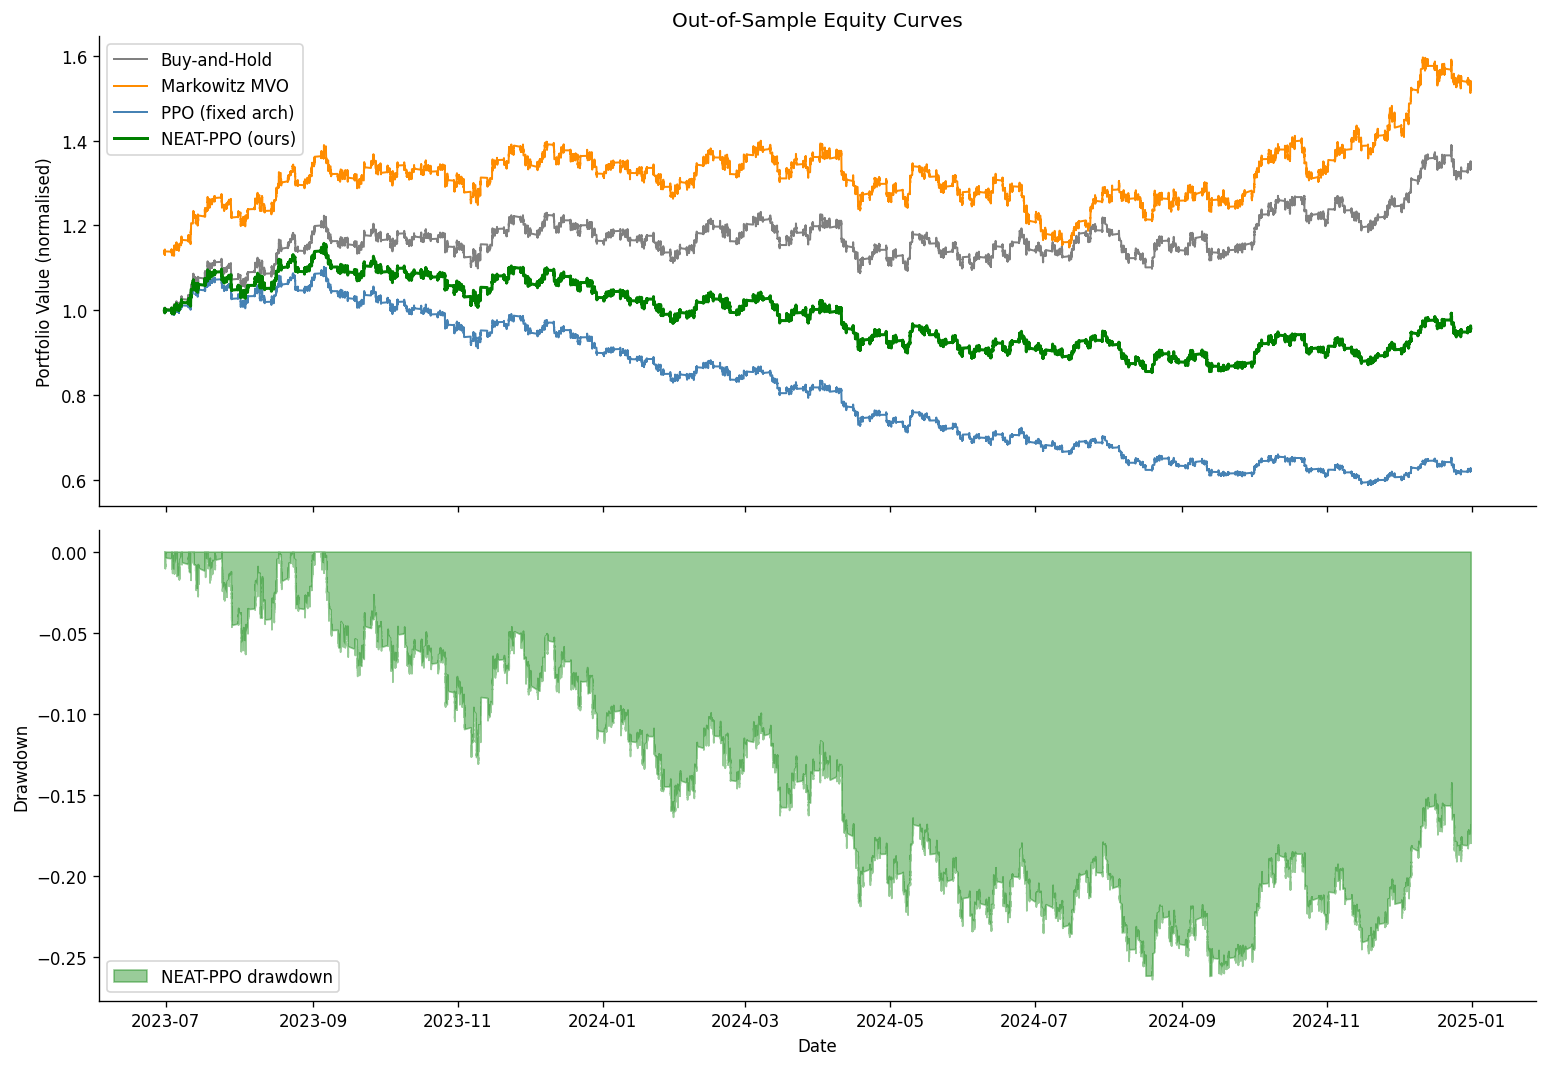

In [21]:
# ── 10.4  Equity curves ────────────────────────────────────────────────────
min_len = min(len(bnh_equity), len(mvo_equity), len(ppo_equity), len(neat_equity))
test_idx_plot = obs_matrix.index[test_mask][:min_len]

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# Top: cumulative equity
ax = axes[0]
ax.plot(test_idx_plot, bnh_equity[:min_len],  lw=1.2, color='gray',       label='Buy-and-Hold')
ax.plot(test_idx_plot, mvo_equity[:min_len],  lw=1.2, color='darkorange',  label='Markowitz MVO')
ax.plot(test_idx_plot, ppo_equity[:min_len],  lw=1.2, color='steelblue',   label='PPO (fixed arch)')
ax.plot(test_idx_plot, neat_equity[:min_len], lw=1.8, color='green',       label='NEAT-PPO (ours)')
ax.set_ylabel('Portfolio Value (normalised)')
ax.set_title('Out-of-Sample Equity Curves')
ax.legend()

# Bottom: drawdown of NEAT-PPO
ax2 = axes[1]
peak_neat = np.maximum.accumulate(neat_equity[:min_len])
dd_neat   = (peak_neat - neat_equity[:min_len]) / (peak_neat + 1e-10)
ax2.fill_between(test_idx_plot, -dd_neat, 0, color='green', alpha=0.4, label='NEAT-PPO drawdown')
ax2.set_ylabel('Drawdown')
ax2.set_xlabel('Date')
ax2.legend()

plt.tight_layout()
plt.savefig('fig_equity_curves.png', bbox_inches='tight')
plt.show()

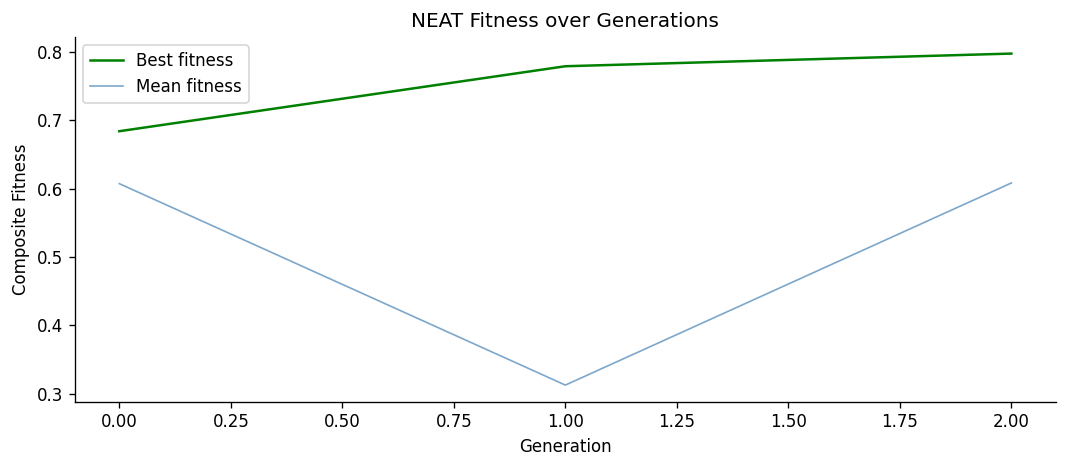

Final best fitness : 0.7973
Best genome nodes  : 16
Best genome conns  : 862
Connection sparsity: 0.8%


In [22]:
# ── 10.5  NEAT fitness evolution ───────────────────────────────────────────
fit_mean = stats_reporter.get_fitness_mean()
fit_max  = stats_reporter.get_fitness_stat(max)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(fit_max,  lw=1.5, color='green',     label='Best fitness')
ax.plot(fit_mean, lw=1.0, color='steelblue', alpha=0.7, label='Mean fitness')
ax.set_xlabel('Generation')
ax.set_ylabel('Composite Fitness')
ax.set_title('NEAT Fitness over Generations')
ax.legend()
plt.tight_layout()
plt.savefig('fig_neat_fitness.png', bbox_inches='tight')
plt.show()

print(f'Final best fitness : {max(fit_max):.4f}')
print(f'Best genome nodes  : {len(best_genome.nodes)}')
print(f'Best genome conns  : {len(best_genome.connections)}')
# Sparsity of best genome
all_w    = [c.weight for c in best_genome.connections.values()]
sparsity = np.mean(np.abs(all_w) < 0.01) if all_w else 0
print(f'Connection sparsity: {sparsity*100:.1f}%')

---
## Summary

| Section | What it does |
|---------|-------------|
| 2 | Synthetic Nifty-50 OHLCV via correlated GBM + macro variables |
| 3 | Feature engineering: momentum, RSI, MACD, vol, rolling z-score normalisation |
| 4 | EDA: price history, return distributions, VIX correlation, rolling correlations |
| 5 | Walk-forward split: train 2016–2021 / val 2022–Jun2023 / test Jul2023–2024 |
| 6 | `PortfolioEnv` Gym environment: softmax weights, 5-bps transaction costs, metrics |
| 7 | NEAT outer loop: genome evaluation, composite fitness (Sharpe − DD + sparsity) |
| 8 | PPO inner loop via Stable-Baselines3 (shared with LSTM baseline) |
| 9 | Baselines: Buy-and-Hold, Markowitz MVO, PPO fixed-arch |
| 10 | Out-of-sample results table + equity curves + NEAT fitness plot |

**To scale up for real training:**
- Set `N_GENERATIONS = 300` in Section 7
- Set `N_PPO_STEPS = 500_000` in Section 8  
- Replace synthetic data with real NSE data (Zerodha Kite / NSE archives)
- Add multi-processing: `neat.ParallelEvaluator` for genome fitness evaluation